### Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sb
import regex as re
from functools import reduce

from sklearn.preprocessing import StandardScaler
from missforest import MissForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor

from datetime import datetime
import pytz

import haversine as hs   
from haversine import Unit

from scipy.interpolate import make_smoothing_spline
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from skforecast.stats._arima import Arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
random.seed(321)
np.random.seed(321)

### Duomenys

In [3]:
meteo_data = pd.read_csv("Meteo_nauji.csv", sep = ',')
meteo_data.head(5)

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,snowDepth,conditionCode
0,2017-11-01 00:00:00,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,0.0,cloudy
1,2017-11-01 01:00:00,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,0.0,cloudy
2,2017-11-01 02:00:00,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,0.0,cloudy
3,2017-11-01 03:00:00,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,0.0,cloudy
4,2017-11-01 04:00:00,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,0.0,cloudy


In [4]:
meteo_data.shape

(73028, 12)

### Duomenų tvarkymas ir paruošimas

In [5]:
clean_meteo_data = meteo_data.drop(columns = ['snowDepth', 'conditionCode'])
clean_meteo_data['observationTimeUtc'] = pd.to_datetime(clean_meteo_data['observationTimeUtc'])
clean_meteo_data.shape

(73028, 10)

Paverčiame į Lietuvos laiką

In [6]:
clean_meteo_data['observationTime'] = (clean_meteo_data['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
clean_meteo_data['observationTime'] = clean_meteo_data['observationTime'].dt.tz_localize(None)
clean_meteo_data = clean_meteo_data.drop(columns = ['observationTimeUtc'])
clean_meteo_data.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,2017-11-01 02:00:00
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,2017-11-01 03:00:00
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,2017-11-01 04:00:00
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,2017-11-01 05:00:00
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,2017-11-01 06:00:00


Praleistų reikšmių analizė

In [7]:
clean_meteo_data.isnull().sum()

airTemperature            58
feelsLikeTemperature      93
windSpeed                 92
windGust                 138
windDirection             87
cloudCover              1605
seaLevelPressure          68
relativeHumidity          71
precipitation             22
observationTime            0
dtype: int64

In [8]:
station_year = clean_meteo_data["observationTime"].dt.year.unique()
station_year.sort()
nan_year_result = []
for year in station_year:
    nan_year_result.append(clean_meteo_data[clean_meteo_data["observationTime"].dt.year == year].isnull().sum())
nan_year_Vilnius = pd.DataFrame(nan_year_result, index = station_year)
nan_year_Vilnius

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
2017,0,0,0,0,0,25,0,0,0,0
2018,0,2,2,8,0,173,1,0,1,0
2019,0,1,1,5,0,130,0,0,3,0
2020,15,20,19,38,18,307,17,18,0,0
2021,0,0,0,1,0,147,0,0,0,0
2022,0,0,0,1,0,272,0,0,0,0
2023,0,0,0,0,0,111,0,0,0,0
2024,32,49,49,53,48,151,32,32,0,0
2025,11,21,21,30,21,263,18,21,18,0
2026,0,0,0,2,0,26,0,0,0,0


In [9]:
clean_meteo_data.groupby(clean_meteo_data['observationTime'].dt.year)['observationTime'].apply(lambda x: x.dt.date.nunique())

observationTime
2017     61
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
2026     61
Name: observationTime, dtype: int64

Praleisti stebėjimai pagal kritulius

In [10]:
pd.set_option('display.max_rows', 500)
clean_meteo_data[clean_meteo_data['precipitation'].isnull()]

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
3973,18.0,18.0,4.8,NaN,166.0,NaN,1021.9,44.0,NaN,2018-04-15 16:00:00
10688,-1.7,NaN,NaN,NaN,237.0,100.0,1013.6,92.0,NaN,2019-01-20 14:00:00
10997,1.1,-3.6,5.0,9.0,123.0,100.0,1008.3,96.0,NaN,2019-02-02 11:00:00
10998,1.4,-3.2,5.1,9.5,138.0,100.0,1008.0,94.0,NaN,2019-02-02 12:00:00
71076,7.5,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 18:00:00
71077,8.0,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 19:00:00
71078,8.5,NaN,NaN,NaN,NaN,NaN,1014.4,NaN,NaN,2025-12-10 20:00:00
71079,8.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-10 21:00:00
71082,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-11 00:00:00
71492,0.8,-4.6,6.3,NaN,306.0,100.0,1001.7,91.0,NaN,2025-12-28 02:00:00


### Praleistų kritulių reikšmių įrašymas

Kaimyninių stočių atrinkimas pagal atstumą

In [11]:
stations = pd.read_csv("Stotys.csv", sep = ',')
stations.head()

,Stotis,Platuma,Ilguma
0,akmenes-ams,56.249920,22.730810
1,alytaus-ams,54.412435,24.063274
2,anyksciu-ams,55.517350,25.117800
3,birstono-ams,54.603217,24.035802
4,birzu-ams,56.193191,24.774184


In [12]:
Vilnius_index = stations[stations['Stotis'] == 'vilniaus-ams'].index
stations_without_Vilnius = stations.drop(Vilnius_index)

In [13]:
Vilnius_coordinates = (54.6872, 25.2797)
stations_distances = []

for i in range(len(stations_without_Vilnius)):
    station_coords = (stations_without_Vilnius['Platuma'].iloc[i], stations_without_Vilnius['Ilguma'].iloc[i])

    distance = hs.haversine(station_coords, Vilnius_coordinates, unit=Unit.KILOMETERS)
    stations_distances.append(distance)

stations_without_Vilnius['Atstumas_iki_Vilniaus'] = stations_distances

In [14]:
stations_without_Vilnius.sort_values('Atstumas_iki_Vilniaus').head()

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus
44,traku-ams,54.615924,24.785292,32.778577
8,elektrenu-ams,54.786161,24.689854,39.432578
36,salcininku-ams,54.310380,25.374422,42.344600
12,kaisiadoriu-ams,54.856942,24.437842,57.200637
25,moletu-ams,55.235244,25.416378,61.561275


In [15]:
ams_dates_data = {
    'akmenes-ams': '2014-07-31', 'alytaus-ams': '2014-07-31', 'anyksciu-ams': '2022-11-10',
    'birstono-ams': '2021-07-03', 'birzu-ams': '2013-10-11', 'dotnuvos-ams': '2013-10-11',
    'druskininku-ams': '2021-07-03', 'duksto-ams': '2013-10-11', 'elektrenu-ams': '2020-10-28',
    'jonavos-ams': '2021-09-05', 'joniskio-ams': '2020-11-14', 'jurbarko-ams': '2020-10-28',
    'kaisiadoriu-ams': '2020-10-17', 'kalvarijos-ams': '2021-07-18', 'kauno-ams': '2013-10-11',
    'kazlu-rudos-ams': '2021-07-18', 'kelmes-ams': '2021-08-07', 'klaipedos-ams': '2013-10-11',
    'kretingos-ams': '2021-07-17', 'kupiskio-ams': '2020-11-13', 'kybartu-ams': '2013-10-11',
    'laukuvos-ams': '2013-10-11', 'lazdiju-ams': '2013-10-11', 'marijampoles-ams': '2014-07-31',
    'mazeikiu-ams': '2014-07-31', 'moletu-ams': '2020-11-06', 'nidos-ams': '2013-10-11',
    'pagegiu-ams': '2021-07-11', 'pakruojo-ams': '2020-11-14', 'panevezio-ams': '2013-10-11',
    'plunges-ams': '2021-08-07', 'prienu-ams': '2021-07-04', 'raseiniu-ams': '2013-10-11',
    'rietavo-ams': '2021-08-06', 'rokiskio-ams': '2014-07-31', 'sakiu-ams': '2020-10-29',
    'salcininku-ams': '2020-10-23', 'seduvos-ams': '2014-07-31', 'siauliu-ams': '2013-10-11',
    'silutes-ams': '2013-10-11', 'skuodo-ams': '2021-08-06', 'svencioniu-ams': '2014-07-31',
    'taurages-ams': '2014-07-31', 'telsiu-ams': '2013-10-11', 'traku-ams': '2020-10-18',
    'ukmerges-ams': '2013-10-11', 'utenos-ams': '2013-10-11', 'varenos-ams': '2013-10-11',
    'ventes-ams': '2020-11-02', 'vezaiciu-ams': '2014-07-31', 'vilniaus-ams': '2013-10-11',
    'zarasu-ams': '2020-11-06'
}

stations_without_Vilnius['Data'] = stations_without_Vilnius['Stotis'].map(ams_dates_data)
stations_without_Vilnius['Data'] = pd.to_datetime(stations_without_Vilnius['Data'])
stations_without_Vilnius.sort_values('Atstumas_iki_Vilniaus').head()

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus,Data
44,traku-ams,54.615924,24.785292,32.778577,2020-10-18
8,elektrenu-ams,54.786161,24.689854,39.432578,2020-10-28
36,salcininku-ams,54.310380,25.374422,42.344600,2020-10-23
12,kaisiadoriu-ams,54.856942,24.437842,57.200637,2020-10-17
25,moletu-ams,55.235244,25.416378,61.561275,2020-11-06


In [16]:
stations_without_Vilnius[stations_without_Vilnius['Data'] < '2016-01-01'].sort_values('Atstumas_iki_Vilniaus').head(10)

,Stotis,Platuma,Ilguma,Atstumas_iki_Vilniaus,Data
47,varenos-ams,54.248271,24.551760,67.785494,2013-10-11
45,ukmerges-ams,55.264145,24.760335,72.209127,2013-10-11
41,svencioniu-ams,55.132777,26.172895,75.593977,2014-07-31
1,alytaus-ams,54.412435,24.063274,84.188443,2014-07-31
46,utenos-ams,55.515321,25.589692,94.170826,2013-10-11
14,kauno-ams,54.883960,23.835880,95.125018,2013-10-11
7,duksto-ams,55.517856,26.316140,113.480953,2013-10-11
5,dotnuvos-ams,55.395993,23.866224,119.669700,2013-10-11
22,lazdiju-ams,54.232210,23.510680,125.028855,2013-10-11
23,marijampoles-ams,54.528855,23.351810,125.395242,2014-07-31


Atrinktos pirmos 6 stotys, atrinktos pagal atstumą iki Vilniaus, nedaugiau kaip 100 km., ir stebėjimų pradžios laiką.

Sujungiami kaimyninių stočių duomenys

In [17]:
def clean_file(file_name):
    file = pd.read_csv(file_name, sep = ',')
    if 'snowDepth' in file:
        file = file.drop(columns=['snowDepth'])

    file['observationTimeUtc'] = pd.to_datetime(file['observationTimeUtc'])
    
    if file_name != 'Meteo_nauji.csv':
        name = re.match(r'([^_]+)', file_name).group(0)
        file = file.rename(columns = {
            'airTemperature' : f'{name}_airTemperature',
            'feelsLikeTemperature' : f'{name}_feelsLikeTemperature',
            'windSpeed' : f'{name}_windSpeed',
            'windGust' : f'{name}_windGust',
            'windDirection' : f'{name}_windDirection',
            'cloudCover' : f'{name}_cloudCover',
            'seaLevelPressure' : f'{name}_seaLevelPressure',
            'relativeHumidity' : f'{name}_relativeHumidity',
            'precipitation' : f'{name}_precipitation',
            'conditionCode' : f'{name}_conditionCode'
        })
    return file

files = ['Meteo_nauji.csv', 'Varenos_meteo_2017_2026.csv', 'Svencioniu_meteo_2017_2026.csv', 'Ukmerges_meteo_2017_2026.csv']
all_dfs = [clean_file(f) for f in files]

meteo_merged = reduce(lambda  left, right: pd.merge(left, right, on='observationTimeUtc', how='outer'), all_dfs)

In [18]:
meteo_merged['observationTime'] = (meteo_merged['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
meteo_merged['observationTime'] = meteo_merged['observationTime'].dt.tz_localize(None)
meteo_merged = meteo_merged.drop(columns = ['observationTimeUtc'])
meteo_merged.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode,...,Ukmerges_feelsLikeTemperature,Ukmerges_windSpeed,Ukmerges_windGust,Ukmerges_windDirection,Ukmerges_cloudCover,Ukmerges_seaLevelPressure,Ukmerges_relativeHumidity,Ukmerges_precipitation,Ukmerges_conditionCode,observationTime
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,cloudy,...,-1.0,0.5,2.3,225.0,100.0,1011.8,96.0,0.0,cloudy,2017-11-01 02:00:00
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,cloudy,...,-0.6,0.7,2.3,225.0,88.0,1011.6,96.0,0.0,cloudy,2017-11-01 03:00:00
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,cloudy,...,-0.3,0.6,2.7,219.0,100.0,1011.6,97.0,0.0,cloudy,2017-11-01 04:00:00
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,cloudy,...,-0.2,0.7,2.7,192.0,100.0,1011.5,98.0,0.0,fog,2017-11-01 05:00:00
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,cloudy,...,0.1,1.3,3.7,197.0,88.0,1011.1,98.0,0.0,fog,2017-11-01 06:00:00


In [19]:
meteo_merged.shape

(73032, 41)

Praleistos reikšmės sujungtąjame rinkinyje

In [20]:
meteo_merged.isnull().sum()

airTemperature                        62
feelsLikeTemperature                  97
windSpeed                             96
windGust                             142
windDirection                         91
cloudCover                          1609
seaLevelPressure                      72
relativeHumidity                      75
precipitation                         26
conditionCode                        408
Varenos_airTemperature                 7
Varenos_feelsLikeTemperature         389
Varenos_windSpeed                    273
Varenos_windGust                     339
Varenos_windDirection                273
Varenos_cloudCover                  1128
Varenos_seaLevelPressure               7
Varenos_relativeHumidity             124
Varenos_precipitation                  7
Varenos_conditionCode                130
Svencioniu_airTemperature             22
Svencioniu_feelsLikeTemperature      163
Svencioniu_windSpeed                 150
Svencioniu_windGust                   25
Svencioniu_windD

Pašalinami stulpeliai turintis visus praleistus stebėjimus

In [21]:
meteo_merged = meteo_merged.dropna(axis=1, how='all')
meteo_merged.shape

(73032, 39)

Kritulių koreliacija tarp atrinktų kaimyninių stočių

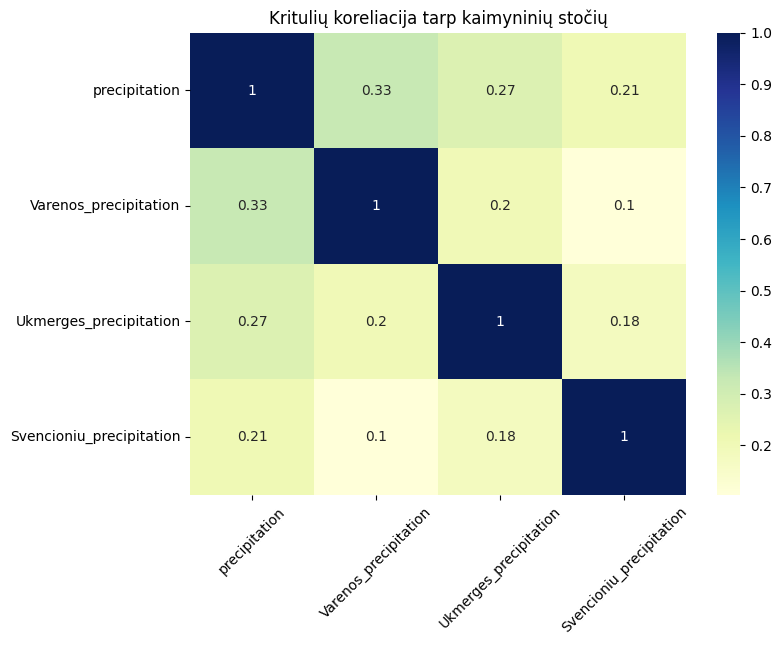

In [22]:
all_stations_precipitation = meteo_merged[['observationTime', 'precipitation', 'Varenos_precipitation', 'Ukmerges_precipitation', 'Svencioniu_precipitation']]

plt.figure(figsize=(8, 6))

precipitation_corr = all_stations_precipitation.corr(numeric_only=True)

sb.heatmap(precipitation_corr, cmap="YlGnBu", annot=True)
plt.xticks(rotation=45)
plt.title("Kritulių koreliacija tarp kaimyninių stočių")
plt.show()

### Kritulių praleistų reikšmių testavimo aibė - block bootstrap metodas

Pirmasis praleistų reikšmių blokas sukūriapmas po 20 % pradinių stebėjimų, kiti blokai paskirstomi po likusį intervalą. Vienas blokas - 12 valandų tarpas. Bendrai pašalinama 10 % stebėjimų.

In [23]:
def block_bootstrapping_testdata(data_column, data_skip = 0.2, p_remove = 0.1, block_size = 12):

    data_array = np.array(data_column, dtype=float)
    N = len(data_array)
    total_to_remove = N * p_remove
    blocks_count =  int(total_to_remove // block_size)
    position = int(N * data_skip)

    step = int((N - position) / blocks_count)
    for block in range(blocks_count):
        if position + block_size < N:
            data_array[position : position + 12] = np.nan
            position += int(step + random.randint(-15, 15))
        else:
            break
    return data_array


In [24]:
data_test_copy1 = meteo_merged.copy()
data_test_copy1['test_precipitation'] = data_test_copy1['precipitation']
data_test_copy1['test_precipitation'] = block_bootstrapping_testdata(data_test_copy1['test_precipitation'])

### Praleistų reikšmių įrašymo metodų išbandymas

Skaitinių stulpelių parinkimas

In [25]:
numeric_data = data_test_copy1.select_dtypes(include='number')
numeric_data = numeric_data.drop(columns=['precipitation'])

Duomenų paruošimas

In [26]:
scaler = StandardScaler()
numeric_data_scaled = pd.DataFrame(scaler.fit_transform(numeric_data), columns=numeric_data.columns, index=numeric_data.index)

Missforest metodas:

In [27]:
mf = MissForest()
miss_forest_data = mf.fit_transform(x=numeric_data_scaled)
# data_test_copy1['missforest_precipitation'] = miss_forest_data['test_precipitation']

missforest_true_data = pd.DataFrame(scaler.inverse_transform(miss_forest_data), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['missforest_precipitation'] = missforest_true_data['test_precipitation']

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [02:19<00:00, 27.85s/it]
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

XGBoost motodas:

In [28]:
xgb = IterativeImputer(estimator=XGBRegressor(n_estimators = 100, random_state = 321), max_iter = 10, random_state = 321)
xgb_transformed = xgb.fit_transform(numeric_data_scaled)
imputed_df_xgb = pd.DataFrame(scaler.inverse_transform(xgb_transformed), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['xgb_precipitation'] = imputed_df_xgb['test_precipitation']


c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MICE metodas:

In [29]:
imputer = IterativeImputer(random_state=321)
imputed_data = imputer.fit_transform(numeric_data_scaled)
meteo_imputed_mice = pd.DataFrame(scaler.inverse_transform(imputed_data), columns=numeric_data.columns, index=numeric_data.index)
data_test_copy1['mice_precipitation'] = meteo_imputed_mice['test_precipitation']

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


SARIMA modelis:

Duomenų paruošimas

In [30]:
y_precipitation = data_test_copy1['precipitation'].values
x_time_number = np.arange(len(y_precipitation))

mask = ~np.isnan(y_precipitation)
x_train = x_time_number[mask]
y_train = y_precipitation[mask]

spl = make_smoothing_spline(x_train, y_train, lam=None)
clean_precipitation_series = spl(x_time_number)

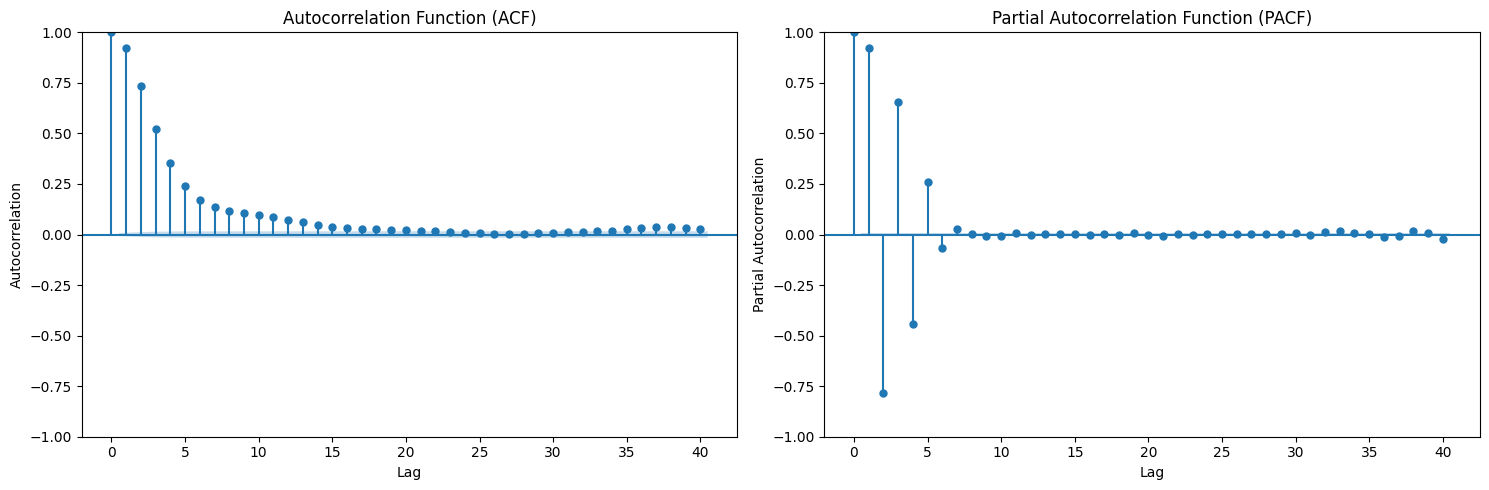

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(clean_precipitation_series, lags=40, ax=ax[0])
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("Autocorrelation")
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(clean_precipitation_series, lags=40, ax=ax[1])
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("Partial Autocorrelation")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [32]:
def check_stationarity(timeseries):
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistika: {result[0]}')
    print(f'p-reikšmė: {p_value}')
    print('Stacionari laiko eilutė' if p_value < 0.05 else 'Nestacionari laiko eilutė')


check_stationarity(clean_precipitation_series)

ADF Statistika: -33.42319420255111
p-reikšmė: 0.0
Stacionari laiko eilutė


In [34]:
model_auto = Arima(
    order = None,  
    seasonal_order = None,
    seasonal = False,
    ic = "aic",
    stepwise = True,
    trace = True
)

model_auto.fit(y=clean_precipitation_series, suppress_warnings=True)

print("-" * 30)
print(f"Geriausi parinkti parametrai: {model_auto.best_params_}")


Fitting models using approximations...

 ARIMA(p,d,q)(P,D,Q)[m]                     : aic
 ------------------------------------------------
 ARIMA(2,0,2) with non-zero mean : -225942.9246
 ARIMA(0,0,0) with non-zero mean : 43279.4102
 ARIMA(1,0,0) with non-zero mean : -95817.4187
 ARIMA(0,0,1) with non-zero mean : -51856.8805
 ARIMA(0,0,0) with zero mean     : 46738.8464
 ARIMA(1,0,2) with non-zero mean : -212513.0400
 ARIMA(2,0,1) with non-zero mean : -213445.1992
 ARIMA(3,0,2) with non-zero mean : -228026.3192
 ARIMA(3,0,2) with zero mean     : -227623.0585
 ARIMA(3,0,1) with non-zero mean : -226205.2897
 ARIMA(4,0,2) with non-zero mean : -228098.9404
 ARIMA(4,0,2) with zero mean     : -227670.3179
 ARIMA(4,0,1) with non-zero mean : -227825.1488
 ARIMA(5,0,2) with non-zero mean : -228186.1062
 ARIMA(5,0,2) with zero mean     : -227812.0956
 ARIMA(5,0,1) with non-zero mean : -228186.5163
 ARIMA(5,0,1) with zero mean     : -227802.1248
 ARIMA(5,0,0) with non-zero mean : -227794.8892
 

In [36]:
sarima = SARIMAX(data_test_copy1['test_precipitation'],
                order=(5, 0, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_results = sarima.fit(disp=False)
data_test_copy1['sarima_precipitation'] = sarima_results.fittedvalues

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data_test_copy1['test_precipitation'], 
              order=(5, 0, 1), 
              trend='c')

model_results = model.fit()
data_test_copy1['sarima_precipitation'] = model_results.fittedvalues

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [38]:
data_test_copy1['sarima_precipitation'].isnull().sum()

np.int64(0)

Įrašymo meotdų palyginimas:

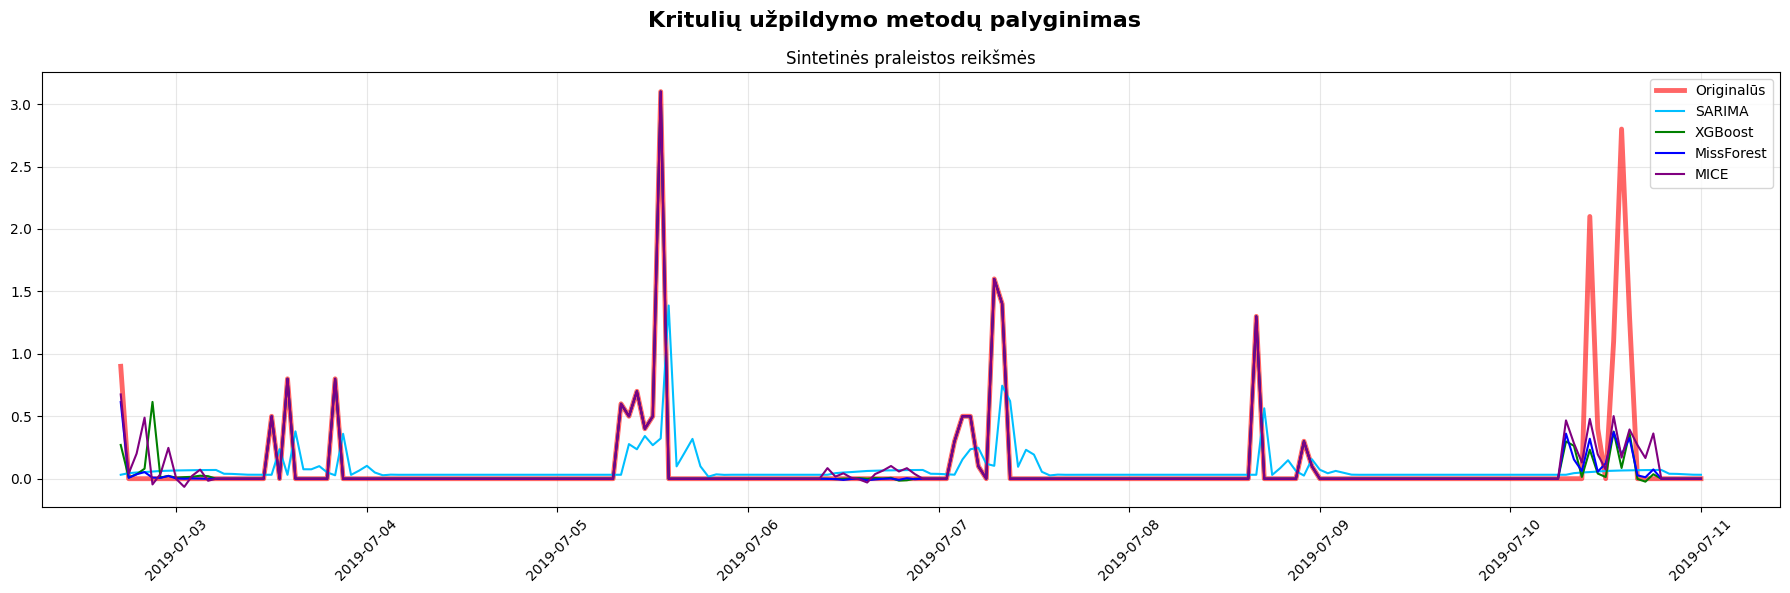

In [39]:
start = int(len(data_test_copy1) * 0.2)
data_first_block = data_test_copy1[start : start + 200]

fig, ax1 = plt.subplots(figsize=(18, 6))
ax1.plot(data_first_block['observationTime'], data_first_block['precipitation'], label='Originalūs', color='red', linewidth=3.5, alpha=0.6)
ax1.plot(data_first_block['observationTime'], data_first_block['sarima_precipitation'], label='SARIMA', color='deepskyblue', linewidth=1.5)
ax1.plot(data_first_block['observationTime'], data_first_block['xgb_precipitation'], label='XGBoost', color='green', linewidth=1.5)
ax1.plot(data_first_block['observationTime'], data_first_block['missforest_precipitation'], label='MissForest', color='blue', linewidth=1.5)
ax1.plot(data_first_block['observationTime'], data_first_block['mice_precipitation'], label='MICE', color='purple', linewidth=1.5)
ax1.set_title('')
ax1.set_title('Sintetinės praleistos reikšmės')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

fig.suptitle('Kritulių užpildymo metodų palyginimas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Metrikų skaičiavimas

In [40]:
synthetic_nan = data_test_copy1['test_precipitation'].isna() & data_test_copy1['precipitation'].notna()
precipitation_true = data_test_copy1.loc[synthetic_nan, 'precipitation']
precipitation_sarima = data_test_copy1.loc[synthetic_nan, 'sarima_precipitation']
precipitation_mf = data_test_copy1.loc[synthetic_nan, 'missforest_precipitation']
precipitation_xgb = data_test_copy1.loc[synthetic_nan, 'xgb_precipitation']
precipitation_mice = data_test_copy1.loc[synthetic_nan, 'mice_precipitation']

precipitation_sarima = precipitation_sarima.clip(lower=0)
precipitation_mf = precipitation_mf.clip(lower=0)
precipitation_xgb = precipitation_xgb.clip(lower=0)
precipitation_mice = precipitation_mice.clip(lower=0)

results = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R^2'],
    'SARIMA': [
        mean_absolute_error(precipitation_true, precipitation_sarima),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_sarima)),
        r2_score(precipitation_true, precipitation_sarima)
    ],
    'MissForest': [
        mean_absolute_error(precipitation_true, precipitation_mf),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_mf)),
        r2_score(precipitation_true, precipitation_mf)
    ],
    'XGBoost': [
        mean_absolute_error(precipitation_true, precipitation_xgb),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_xgb)),
        r2_score(precipitation_true, precipitation_xgb)
    ],
    'MICE': [
        mean_absolute_error(precipitation_true, precipitation_mice),
        np.sqrt(mean_squared_error(precipitation_true, precipitation_mice)),
        r2_score(precipitation_true, precipitation_mice)
    ]
})

print(results)

  Metrika    SARIMA  MissForest   XGBoost      MICE
0     MAE  0.123178    0.068675  0.073797  0.107163
1    RMSE  0.474433    0.392677  0.386641  0.433835
2     R^2  0.031368    0.336441  0.356682  0.190049


Toliau dirbsime su Missforest praleistų kritulių užpildytomis reikšmėmis

In [ ]:
# numeric_data = clean_meteo_data.select_dtypes(include='number')

# xgb = IterativeImputer(estimator=XGBRegressor(n_estimators = 100, random_state = 321), max_iter = 10, random_state = 321)
# xgb_transformed = xgb.fit_transform(numeric_data)
# imputed_df_xgb = pd.DataFrame(xgb_transformed, columns=numeric_data.columns, index=numeric_data.index)
# clean_meteo_data['xgb_precipitation'] = imputed_df_xgb['precipitation']

numeric_data = data_test_copy1.select_dtypes(include='number')

mf = MissForest()
miss_forest_data = mf.fit_transform(x=numeric_data)
clean_meteo_data['missforest_precipitation'] = miss_forest_data['precipitation']


In [ ]:
time_mask1 = (clean_meteo_data['observationTime'] >= '2025-12-10') & (clean_meteo_data['observationTime'] <= '2025-12-12')
time_mask2 = (clean_meteo_data['observationTime'] >= '2025-12-27') & (clean_meteo_data['observationTime'] <= '2026-01-01')
filtered_data1 = clean_meteo_data[time_mask1]
filtered_data2 = clean_meteo_data[time_mask2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

ax1.plot(filtered_data1['observationTime'], filtered_data1['precipitation'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax1.plot(filtered_data1['observationTime'], filtered_data1['missforest_precipitation'], label='Missforest', color='blue', linewidth=1.5)
ax1.set_title('2025-12-10 iki 2025-12-12 (Trumpesnės spragos)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.plot(filtered_data2['observationTime'], filtered_data2['precipitation'], label='Originalūs', color='red', linewidth=6, alpha=0.4)
ax2.plot(filtered_data2['observationTime'], filtered_data2['missforest_precipitation'], label='Missforest', color='blue', linewidth=1.5)
ax2.set_title('2025-12-27 iki 2026-01-01 (Didesnė spraga)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Kritulių užpildymo metodų palyginimas (tikrosios praleistos reikšmės, tikroji aibė)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
clean_meteo_data = clean_meteo_data.drop(columns = ['precipitation'])
clean_meteo_data.head(5)

Duomenų aibės agregavimas

In [ ]:
agg_logic = {
    'airTemperature': 'mean',
    'feelsLikeTemperature': 'mean',
    'windSpeed': 'mean',
    'windGust': 'max',
    'windDirection': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cloudCover': 'mean',
    'seaLevelPressure': 'mean',
    'relativeHumidity': 'mean',
    'missforest_precipitation': 'sum'
}

agg_meteo_data = clean_meteo_data.groupby(clean_meteo_data["observationTime"].dt.date).agg(agg_logic)
agg_meteo_data = agg_meteo_data.reset_index()
agg_meteo_data["observationTime"] = pd.to_datetime(agg_meteo_data["observationTime"])
agg_meteo_data

In [ ]:
agg_meteo_data.isnull().sum()

In [ ]:
agg_meteo_data[agg_meteo_data['cloudCover'].isnull()]

Praleistų reikšmių užpildymas naudojant slankujį vidurkį.

Pirmiausia sukūriama testavimo aibė.

In [ ]:
agg_meteo_data_copy = agg_meteo_data.copy()
agg_meteo_data_copy['test_cloudCover'] = agg_meteo_data_copy['cloudCover']

data_test_mask2_1 = (agg_meteo_data_copy['observationTime'] >= '2025-12-10') & (agg_meteo_data_copy['observationTime'] < '2025-12-15')
agg_meteo_data_copy.loc[agg_meteo_data_copy[data_test_mask2_1].index, 'test_cloudCover'] = np.nan

data_test_mask2_2 = (agg_meteo_data_copy['observationTime'] >= '2025-11-13') & (agg_meteo_data_copy['observationTime'] < '2025-11-15')
agg_meteo_data_copy.loc[agg_meteo_data_copy[data_test_mask2_2].index, 'test_cloudCover'] = np.nan

In [ ]:
time_mask_cloud = (agg_meteo_data_copy['observationTime'] >= '2025-11-01') & (agg_meteo_data_copy['observationTime'] <= '2025-12-31')
filtered_data_cloud = agg_meteo_data_copy[time_mask_cloud]

fig, (ax1) = plt.subplots(1, figsize=(18, 6))

ax1.plot(filtered_data_cloud['observationTime'], filtered_data_cloud['cloudCover'], label='Originalūs', color='red', linewidth=4, alpha=0.4)
ax1.plot(filtered_data_cloud['observationTime'], filtered_data_cloud['test_cloudCover'], label='Testavimo', color='blue', linewidth=1.5)
ax1.set_title('Pašalinti 2 ir 5 dienų intervalai')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

fig.suptitle('Orginalūs debesuotumo stebėjimai ir testavimo aibė', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
smooth_values1 = agg_meteo_data_copy['test_cloudCover'].rolling(window=6, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed_6'] = agg_meteo_data_copy['test_cloudCover'].fillna(smooth_values1)

smooth_values2 = agg_meteo_data_copy['test_cloudCover'].rolling(window=8, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed_8'] = agg_meteo_data_copy['test_cloudCover'].fillna(smooth_values2)

smooth_values3 = agg_meteo_data_copy['test_cloudCover'].rolling(window=10, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed_10'] = agg_meteo_data_copy['test_cloudCover'].fillna(smooth_values3)

smooth_values4 = agg_meteo_data_copy['test_cloudCover'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed_12'] = agg_meteo_data_copy['test_cloudCover'].fillna(smooth_values4)

smooth_values5 = agg_meteo_data_copy['cloudCover_fixed_6'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed_6_12'] = agg_meteo_data_copy['cloudCover_fixed_6'].fillna(smooth_values5)

time_mask_cloud2 = (agg_meteo_data_copy['observationTime'] >= '2025-11-01') & (agg_meteo_data_copy['observationTime'] <= '2025-12-31')
filtered_data_cloud2 = agg_meteo_data_copy[time_mask_cloud2]

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(filtered_data_cloud2['observationTime'], filtered_data_cloud2['cloudCover'], label='Orginalūs', color='red', linewidth=3, alpha=0.6)
ax.plot(filtered_data_cloud2['observationTime'], filtered_data_cloud2['cloudCover_fixed_8'], label='window = 8', color='grey', linewidth=1.5)
ax.plot(filtered_data_cloud2['observationTime'], filtered_data_cloud2['cloudCover_fixed_10'], label='window = 10', color='green', linewidth=1.5, linestyle='--')
ax.plot(filtered_data_cloud2['observationTime'], filtered_data_cloud2['cloudCover_fixed_12'], label='window = 12', color='blue', linewidth=1.5)
ax.plot(filtered_data_cloud2['observationTime'], filtered_data_cloud2['cloudCover_fixed_6_12'], label='window = 6 ir window = 12', color='orange', linewidth=1.5, linestyle='--')
ax.set_title('Pašalinti 2 ir 5 dienų intervalai')
ax.grid()
ax.legend()

fig.suptitle('Debesuotumo praleistų reikšmių įrašymas (testavimo aibė)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
time_mask_cloud = (agg_meteo_data_copy['observationTime'] >= '2025-11-01') & (agg_meteo_data_copy['observationTime'] <= '2025-12-16')
filtered_data_cloud = agg_meteo_data_copy[time_mask_cloud]

validation_mask = filtered_data_cloud['test_cloudCover'].isna() & filtered_data_cloud['cloudCover'].notna()
cloudCover_true = filtered_data_cloud.loc[validation_mask, 'cloudCover']
cloudCover_window_8 = filtered_data_cloud.loc[validation_mask, 'cloudCover_fixed_8']
cloudCover_window_10 = filtered_data_cloud.loc[validation_mask, 'cloudCover_fixed_10']
cloudCover_window_12 = filtered_data_cloud.loc[validation_mask, 'cloudCover_fixed_12']
cloudCover_window_6_12 = filtered_data_cloud.loc[validation_mask, 'cloudCover_fixed_6_12']

results = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R^2'],
    'window_8': [
        mean_absolute_error(cloudCover_true, cloudCover_window_8),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_window_8)),
        r2_score(cloudCover_true, cloudCover_window_8)
    ],
    'window_10': [
        mean_absolute_error(cloudCover_true, cloudCover_window_10),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_window_10)),
        r2_score(cloudCover_true, cloudCover_window_10)
    ],
    'window_12': [
        mean_absolute_error(cloudCover_true, cloudCover_window_12),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_window_12)),
        r2_score(cloudCover_true, cloudCover_window_12)
    ],
    'window_6_12': [
        mean_absolute_error(cloudCover_true, cloudCover_window_6_12),
        np.sqrt(mean_squared_error(cloudCover_true, cloudCover_window_6_12)),
        r2_score(cloudCover_true, cloudCover_window_6_12)
    ]

})

print(results)

In [ ]:
smooth_values1 = agg_meteo_data['cloudCover'].rolling(window=6, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_6'] = agg_meteo_data['cloudCover'].fillna(smooth_values1)

smooth_values2 = agg_meteo_data['cloudCover'].rolling(window=8, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_8'] = agg_meteo_data['cloudCover'].fillna(smooth_values2)

smooth_values3 = agg_meteo_data['cloudCover'].rolling(window=10, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_10'] = agg_meteo_data['cloudCover'].fillna(smooth_values3)

smooth_values4 = agg_meteo_data['cloudCover'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_12'] = agg_meteo_data['cloudCover'].fillna(smooth_values4)

smooth_values6 = agg_meteo_data['cloudCover_fixed_6'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_6_12'] = agg_meteo_data['cloudCover_fixed_6'].fillna(smooth_values6)

time_mask = (agg_meteo_data['observationTime'] > '2020-11-01') & (agg_meteo_data['observationTime'] < '2021-01-01')
filtered_data = agg_meteo_data[time_mask]


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover'], label='Orginalūs', color='red', linewidth=4, alpha=0.6)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_8'], label='window = 8', color='grey', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_12'], label='window = 12', color='blue', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_10'], label='window = 10', color='green', linewidth=1.5, linestyle='--')
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_6_12'], label='window = 6 ir window = 12', color='orange', linewidth=1.5, linestyle='--')
ax.set_title('Debesuotumas')
ax.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
agg_meteo_data = agg_meteo_data.drop(columns = ['cloudCover', 'cloudCover_fixed_6', 'cloudCover_fixed_12', 'cloudCover_fixed_6_12', 'cloudCover_fixed_8'])
agg_meteo_data.head(5)

In [ ]:
agg_meteo_data.isnull().sum()

In [ ]:
cols_to_fix = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection']

for col in cols_to_fix:
    smooth = agg_meteo_data[col].rolling(window=10, min_periods=2, center=True).mean()
    agg_meteo_data[f'{col}_fixed'] = agg_meteo_data[col].fillna(smooth)

agg_meteo_data = agg_meteo_data.drop(columns = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection'])
agg_meteo_data = agg_meteo_data.rename(columns={'cloudCover_fixed_10': 'cloudCover_fixed'})
agg_meteo_data.head(5)

Duomenų įrašymas

In [ ]:
agg_meteo_data.shape

In [ ]:
# agg_meteo_data.to_csv('Vilnius_meteo_data_new_2017_2026.csv', index=False, encoding='utf-8-sig')

In [ ]:
agg_meteo_data_copy[agg_meteo_data_copy['observationTime'] >= '2020-01-01'].head(5)

Atstumai

In [ ]:
# !pip install haversine